In [ ]:
from google.colab import files
files.upload() #Upload kaggle.json here

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"aasxlilov","key":"b815f279f04c771851303e5d022b0f98"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d sujaykapadnis/emotion-recognition-dataset

Dataset URL: https://www.kaggle.com/datasets/sujaykapadnis/emotion-recognition-dataset
License(s): CC-BY-NC-SA-4.0


In [ ]:
import zipfile

with zipfile.ZipFile('/content/emotion-recognition-dataset.zip') as zip_ref:
    zip_ref.extractall()

In [ ]:
import shutil

shutil.rmtree('/content/dataset/Ahegao')

In [ ]:
import os

for dirpath,dirnames,filenames in os.walk("/content/dataset"):
    print(f'There are {len(dirnames)} directories and {len(filenames)} images in "{dirpath}"')

There are 5 directories and 0 images in "/content/dataset"
There are 0 directories and 1313 images in "/content/dataset/Angry"
There are 0 directories and 4027 images in "/content/dataset/Neutral"
There are 0 directories and 1234 images in "/content/dataset/Surprise"
There are 0 directories and 3740 images in "/content/dataset/Happy"
There are 0 directories and 3934 images in "/content/dataset/Sad"


In [ ]:
import tensorflow as tf

IMG_SIZE = (224,224)

data_path = '/content/dataset'

train_data = tf.keras.preprocessing.image_dataset_from_directory(data_path,
                                                                 label_mode = 'categorical',
                                                                 image_size = IMG_SIZE,
                                                                 crop_to_aspect_ratio = True,
                                                                 subset = 'training',
                                                                 validation_split = 0.2,
                                                                 seed = 42)

test_data = tf.keras.preprocessing.image_dataset_from_directory(data_path,
                                                                 label_mode = 'categorical',
                                                                 image_size = IMG_SIZE,
                                                                 crop_to_aspect_ratio = True,
                                                                 subset = 'validation',
                                                                 validation_split = 0.2,
                                                                 seed = 42)

Found 14248 files belonging to 5 classes.
Using 11399 files for training.
Found 14248 files belonging to 5 classes.
Using 2849 files for validation.


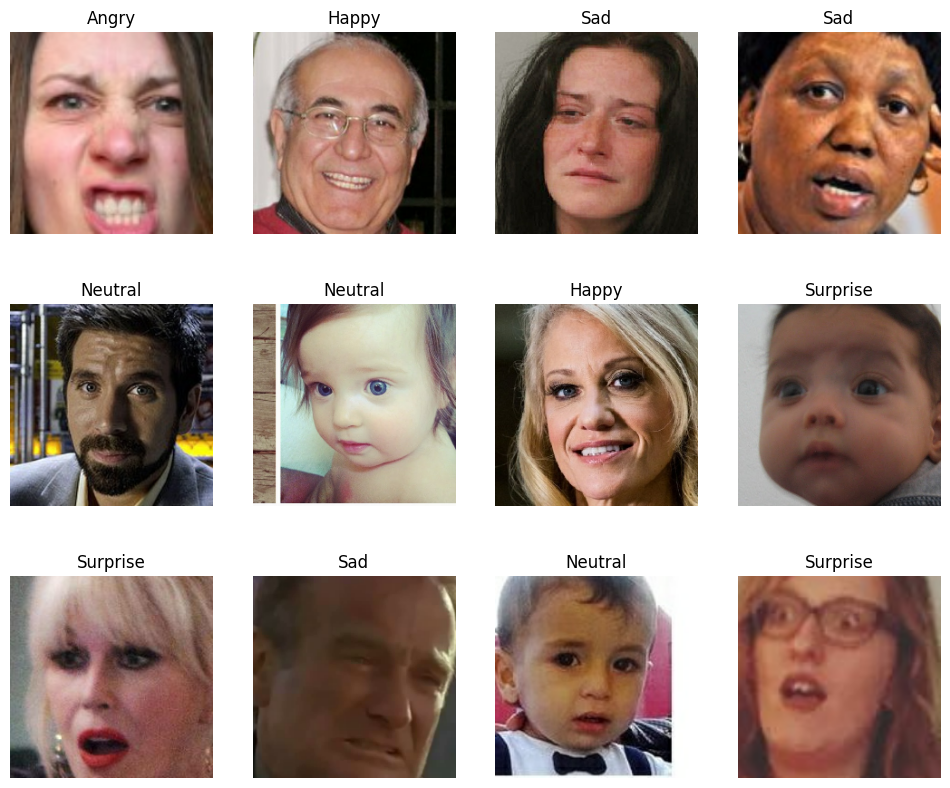

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class_names = train_data.class_names
plt.figure(figsize=(12,10))
for images , labels in train_data.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[np.argmax(labels[i].numpy())])
        plt.axis("off")

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224,224,3)),
    tf.keras.layers.Rescaling(1/255.),
    tf.keras.layers.Conv2D(64,kernel_size=7,strides = 3,padding = 'same',activation = 'relu',kernel_initializer = 'he_normal'),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(128,kernel_size=3,padding = 'same',activation = 'relu',kernel_initializer = 'he_normal'),
    tf.keras.layers.Conv2D(128,kernel_size=3,padding = 'same',activation = 'relu',kernel_initializer = 'he_normal'),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(256,kernel_size=3,padding = 'same',activation = 'relu',kernel_initializer = 'he_normal'),
    tf.keras.layers.Conv2D(256,kernel_size=3,padding = 'same',activation = 'relu',kernel_initializer = 'he_normal'),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu',kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(64,activation='relu',kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(class_names),activation='softmax')
])

In [ ]:
model.compile(loss ='categorical_crossentropy',
               optimizer = tf.keras.optimizers.Adam(),
               metrics = ['accuracy','f1_score'])
history1 = model.fit(train_data,epochs=5, validation_data=test_data)

Epoch 1/5
357/357 ━━━━━━━━━━━━━━━━━━━━ 70s 168ms/step - accuracy: 0.2629 - f1_score: 0.1751 - loss: 1.6419 - val_accuracy: 0.3040 - val_f1_score: 0.1559 - val_loss: 1.4758
Epoch 2/5
357/357 ━━━━━━━━━━━━━━━━━━━━ 60s 127ms/step - accuracy: 0.2849 - f1_score: 0.1852 - loss: 1.4788 - val_accuracy: 0.3187 - val_f1_score: 0.2074 - val_loss: 1.4487
Epoch 3/5
357/357 ━━━━━━━━━━━━━━━━━━━━ 42s 117ms/step - accuracy: 0.3313 - f1_score: 0.2202 - loss: 1.4352 - val_accuracy: 0.4230 - val_f1_score: 0.3466 - val_loss: 1.3393
Epoch 4/5
357/357 ━━━━━━━━━━━━━━━━━━━━ 86s 129ms/step - accuracy: 0.4055 - f1_score: 0.3147 - loss: 1.3455 - val_accuracy: 0.5009 - val_f1_score: 0.4134 - val_loss: 1.1942
Epoch 5/5
357/357 ━━━━━━━━━━━━━━━━━━━━ 79s 122ms/step - accuracy: 0.4704 - f1_score: 0.3768 - loss: 1.2495 - val_accuracy: 0.5335 - val_f1_score: 0.4418 - val_loss: 1.1224


In [ ]:
inputs = tf.keras.layers.Input(shape = (224,224,3))

x=tf.keras.applications.resnet50.preprocess_input(inputs)

base_model = tf.keras.applications.resnet50.ResNet50(include_top = False,input_tensor=x)

avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)

output = tf.keras.layers.Dense(5,activation = 'softmax')(avg)

model = tf.keras.Model(inputs = base_model.input,outputs = output)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
initial_learning_rate = 0.01
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps = 200,
    decay_rate =0.96
)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights = True
)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    'emotion_detector.keras',
    save_best_only=True
)
model.compile(
    loss = 'categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate = lr_schedule),
    metrics = ['accuracy','f1_score']
)
history2  = model.fit(train_data,epochs = 15,validation_data = test_data,
                      callbacks = [early_stopping,checkpoint_cb])

Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_35']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


357/357 ━━━━━━━━━━━━━━━━━━━━ 78s 183ms/step - accuracy: 0.4817 - f1_score: 0.4495 - loss: 1.8939 - val_accuracy: 0.5742 - val_f1_score: 0.4810 - val_loss: 1.5968
Epoch 2/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 60s 138ms/step - accuracy: 0.6189 - f1_score: 0.6032 - loss: 1.1872 - val_accuracy: 0.6157 - val_f1_score: 0.6228 - val_loss: 1.1864
Epoch 3/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 79s 128ms/step - accuracy: 0.6463 - f1_score: 0.6357 - loss: 1.0473 - val_accuracy: 0.5788 - val_f1_score: 0.5330 - val_loss: 1.5166
Epoch 4/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 103s 187ms/step - accuracy: 0.6833 - f1_score: 0.6795 - loss: 0.9539 - val_accuracy: 0.5525 - val_f1_score: 0.5383 - val_loss: 1.6520
Epoch 5/15
357/357 ━━━━━━━━━━━━━━━━━━━━ 56s 156ms/step - accuracy: 0.7004 - f1_score: 0.6957 - loss: 0.8797 - val_accuracy: 0.5581 - val_f1_score: 0.5468 - val_loss: 1.6667


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted class:Sad


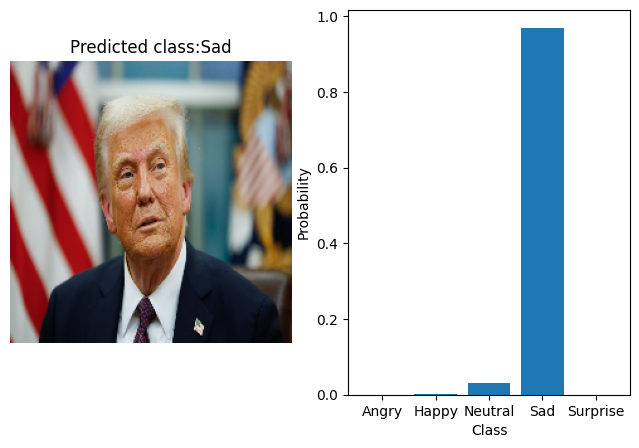

In [ ]:
import matplotlib.image as  mpimg

def pred_and_plot(model,image_path):
    plt.figure(figsize = (8,5))
    image = mpimg.imread(image_path)
    image = tf.image.resize(image,(224,224))
    pred_probs = model.predict(np.expand_dims(image,axis = 0))
    plt.subplot(1,2,1)
    plt.imshow(image/255)
    pred = class_names[np.argmax(pred_probs)]
    plt.title(f'Predicted class:{pred}')
    plt.axis('off')
    print(f'Predicted class:{pred}')
    plt.subplot(1,2,2)
    plt.bar(class_names,pred_probs[0])
    plt.xlabel('Class')
    plt.ylabel('Probability')
    plt.show()

pred_and_plot(model,'/content/licensed-image (1).jpg')